# 05 - Zero-Shot Transfer from Text Embeddings to Image Embeddings

## Objective

The decoder developed in the previous notebooks was trained entirely using
CLIP text embeddings.

Training:

caption
→ frozen CLIP text encoder
→ L2-normalized text embedding
→ Mini-NOVIC decoder
→ object noun

The decoder has never been trained using image-label pairs.

This notebook performs the central NOVIC-style experiment:

image
→ frozen CLIP image encoder
→ L2-normalized image embedding
→ SAME trained Mini-NOVIC decoder
→ generated object noun

No decoder retraining is performed.

The goals are:

1. Load the same CLIP model used to generate the training text embeddings.
2. Load the best decoder checkpoint from Notebook 04.
3. Build a small controlled image test set.
4. Preprocess and encode test images with the CLIP image encoder.
5. L2-normalize image embeddings.
6. Feed image embeddings directly into the text-trained decoder.
7. Generate object nouns autoregressively.
8. Measure exact image classification accuracy.
9. Inspect qualitative successes and failures.
10. Compare image embeddings with corresponding text embeddings.

This experiment tests whether semantic information learned from CLIP text
embeddings transfers to CLIP image embeddings.

## 1. Environment setup

In [112]:
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [113]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


## 2. Persistent storage

The trained decoder checkpoint from Notebook 04 and the controlled image test set
are stored in Google Drive.

In [114]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [115]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/mini_novic_storage"
)

EMBEDDING_CACHE = (
    DRIVE_ROOT
    / "embeddings"
    / "text_embedding_dataset"
    / "clip_text_embeddings.pt"
)

DECODER_CHECKPOINT = (
    DRIVE_ROOT
    / "checkpoints"
    / "full_decoder_training"
    / "best_full_decoder.pt"
)

IMAGE_TEST_DIR = (
    DRIVE_ROOT
    / "datasets"
    / "image_transfer_test"
)

RESULT_DIR = (
    DRIVE_ROOT
    / "results"
    / "zero_shot_image_transfer"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

IMAGE_TEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Decoder checkpoint:", DECODER_CHECKPOINT)
print("Image test directory:", IMAGE_TEST_DIR)
print("Result directory:", RESULT_DIR)

Decoder checkpoint: /content/drive/MyDrive/mini_novic_storage/checkpoints/full_decoder_training/best_full_decoder.pt
Image test directory: /content/drive/MyDrive/mini_novic_storage/datasets/image_transfer_test
Result directory: /content/drive/MyDrive/mini_novic_storage/results/zero_shot_image_transfer


# Install OpenCLIP
Colab usually already has PyTorch.

In [116]:
!pip install -q open_clip_torch

In [117]:
import open_clip

print("OpenCLIP imported successfully")

OpenCLIP imported successfully


## 3. Recover the original CLIP configuration

The image encoder used here must come from the exact same CLIP checkpoint that
produced the text embeddings used during decoder training.

Mixing embeddings from different CLIP models would make the experiment invalid.## 3. Recover the original CLIP configuration

The image encoder used here must come from the exact same CLIP checkpoint that
produced the text embeddings used during decoder training.

Mixing embeddings from different CLIP models would make the experiment invalid.

In [118]:
embedding_cache = torch.load(
    EMBEDDING_CACHE,
    map_location="cpu"
)

MODEL_NAME = embedding_cache["model_name"]
PRETRAINED = embedding_cache["pretrained"]

print("Original CLIP model:", MODEL_NAME)
print("Original pretrained weights:", PRETRAINED)

Original CLIP model: ViT-B-32
Original pretrained weights: laion2b_s34b_b79k


## 4. Load the frozen CLIP image encoder

The same multimodal model used on the text side is now used on the image side.

Only the image encoder path changes.

The CLIP model remains completely frozen.

In [119]:
clip_model, _, preprocess = (
    open_clip.create_model_and_transforms(
        MODEL_NAME,
        pretrained=PRETRAINED
    )
)

clip_tokenizer = open_clip.get_tokenizer(
    MODEL_NAME
)

clip_model = clip_model.to(device)
clip_model.eval()

for parameter in clip_model.parameters():
    parameter.requires_grad = False

print("CLIP loaded")
print("Device:", next(clip_model.parameters()).device)

CLIP loaded
Device: cuda:0


In [120]:
trainable_clip_parameters = sum(
    p.numel()
    for p in clip_model.parameters()
    if p.requires_grad
)

print(
    "Trainable CLIP parameters:",
    trainable_clip_parameters
)

Trainable CLIP parameters: 0


## 5. Load the text-trained decoder checkpoint

The decoder is loaded exactly as trained in Notebook 04.

No image-side optimization or fine-tuning is performed.

In [121]:
checkpoint = torch.load(
    DECODER_CHECKPOINT,
    map_location=device
)

print("Checkpoint epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])

Checkpoint epoch: 29
Validation loss: 3.053483774419874e-05


## Recover configuration:

In [122]:
CLIP_DIM = checkpoint["clip_dim"]
HIDDEN_DIM = checkpoint["hidden_dim"]
PREFIX_LEN = checkpoint["prefix_len"]
NUM_LAYERS = checkpoint["num_layers"]
NUM_HEADS = checkpoint["num_heads"]
MAX_SEQ_LEN = checkpoint["max_seq_len"]

vocab = checkpoint["vocab"]
token_to_id = checkpoint["token_to_id"]
id_to_token = checkpoint["id_to_token"]

PAD_ID = checkpoint["pad_id"]
EOS_ID = checkpoint["eos_id"]

VOCAB_SIZE = len(vocab)

print("CLIP dim:", CLIP_DIM)
print("Hidden dim:", HIDDEN_DIM)
print("Prefix length:", PREFIX_LEN)
print("Vocabulary size:", VOCAB_SIZE)

CLIP dim: 512
Hidden dim: 256
Prefix length: 4
Vocabulary size: 58


# Recreate the exact decoder architecture

In [123]:
def build_attention_mask(
    prefix_len,
    token_len,
    device
):

    total_len = (
        prefix_len
        + token_len
    )

    mask = torch.full(
        (total_len, total_len),
        float("-inf"),
        device=device
    )

    # Prefix tokens freely attend
    # to all prefix tokens.
    mask[
        :prefix_len,
        :prefix_len
    ] = 0

    # Generated tokens:
    # all prefixes + current/previous tokens.
    for i in range(token_len):

        row = prefix_len + i

        mask[
            row,
            :prefix_len + i + 1
        ] = 0

    return mask

# Decoder:

In [124]:
class MiniNOVICDecoder(nn.Module):

    def __init__(
        self,
        clip_dim,
        vocab_size,
        hidden_dim=256,
        prefix_len=4,
        max_seq_len=4,
        num_layers=4,
        num_heads=4,
        dropout=0.1,
    ):

        super().__init__()

        self.hidden_dim = hidden_dim
        self.prefix_len = prefix_len
        self.max_seq_len = max_seq_len

        self.prefix_mapper = nn.Linear(
            clip_dim,
            prefix_len * hidden_dim
        )

        self.token_embedding = nn.Embedding(
            vocab_size,
            hidden_dim
        )

        self.position_embedding = nn.Embedding(
            prefix_len + max_seq_len,
            hidden_dim
        )

        transformer_layer = (
            nn.TransformerEncoderLayer(
                d_model=hidden_dim,
                nhead=num_heads,
                dim_feedforward=hidden_dim * 4,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True,
            )
        )

        self.transformer = (
            nn.TransformerEncoder(
                transformer_layer,
                num_layers=num_layers
            )
        )

        self.output_projection = nn.Linear(
            hidden_dim,
            vocab_size
        )

    def forward(
        self,
        clip_embeddings,
        token_ids
    ):

        batch_size = clip_embeddings.size(0)

        # CLIP embedding -> prefix vectors
        prefix = self.prefix_mapper(
            clip_embeddings
        )

        prefix = prefix.view(
            batch_size,
            self.prefix_len,
            self.hidden_dim
        )

        # Generated token IDs -> vectors
        token_vectors = self.token_embedding(
            token_ids
        )

        # Prefix + generated tokens
        x = torch.cat(
            [
                prefix,
                token_vectors
            ],
            dim=1
        )

        total_len = x.size(1)

        # Positional embeddings
        positions = torch.arange(
            total_len,
            device=x.device
        )

        x = (
            x
            + self.position_embedding(
                positions
            ).unsqueeze(0)
        )

        # Prefix-aware causal mask
        mask = build_attention_mask(
            self.prefix_len,
            token_ids.size(1),
            x.device
        )

        # Transformer
        x = self.transformer(
            x,
            mask=mask
        )

        # Shifted prediction states
        prediction_states = x[
            :,
            self.prefix_len - 1:,
            :
        ]

        logits = self.output_projection(
            prediction_states
        )

        return logits

In [125]:
decoder = MiniNOVICDecoder(
    clip_dim=CLIP_DIM,
    vocab_size=VOCAB_SIZE,
    hidden_dim=HIDDEN_DIM,
    prefix_len=PREFIX_LEN,
    max_seq_len=MAX_SEQ_LEN,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    dropout=0.1,
).to(device)

/tmp/ipykernel_2026/4255278610.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


## Load weights:

In [126]:
decoder.load_state_dict(
    checkpoint["model_state_dict"]
)

decoder.eval()

print("Decoder checkpoint loaded successfully.")

Decoder checkpoint loaded successfully.


# Verify model parameter loading

In [127]:
num_parameters = sum(
    p.numel()
    for p in decoder.parameters()
)

print(
    f"Decoder parameters: "
    f"{num_parameters:,}"
)

Decoder parameters: 3,716,154


# Recreate token decoding

In [128]:
def decode_tokens(token_ids):

    words = []

    for token_id in token_ids:

        if token_id == EOS_ID:
            break

        if token_id == PAD_ID:
            continue

        words.append(
            id_to_token[token_id]
        )

    return " ".join(words)

# Greedy generation

In [129]:
@torch.no_grad()
def generate_greedy(
    model,
    clip_embedding,
    max_length=MAX_SEQ_LEN
):

    model.eval()

    if clip_embedding.dim() == 1:

        clip_embedding = (
            clip_embedding.unsqueeze(0)
        )

    clip_embedding = (
        clip_embedding.to(device)
    )

    generated = []

    for _ in range(max_length):

        if len(generated) == 0:

            token_inputs = torch.empty(
                (1, 0),
                dtype=torch.long,
                device=device
            )

        else:

            token_inputs = torch.tensor(
                [generated],
                dtype=torch.long,
                device=device
            )

        logits = model(
            clip_embedding,
            token_inputs
        )

        next_logits = logits[
            :,
            -1,
            :
        ]

        next_token = (
            next_logits
            .argmax(dim=-1)
            .item()
        )

        if next_token == EOS_ID:
            break

        if next_token == PAD_ID:
            break

        generated.append(
            next_token
        )

    return generated

## 6. Controlled image test set

Each subdirectory represents the expected object noun.

These labels are used only for evaluation.

No image or image label is used to update the decoder.

In [130]:
image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

image_records = []

for noun_dir in IMAGE_TEST_DIR.iterdir():

    if not noun_dir.is_dir():
        continue

    expected_noun = noun_dir.name

    for image_path in noun_dir.iterdir():

        if (
            image_path.suffix.lower()
            in image_extensions
        ):

            image_records.append({
                "image_path":
                    str(image_path),

                "expected":
                    expected_noun
            })

image_df = pd.DataFrame(
    image_records
)

print(
    "Number of test images:",
    len(image_df)
)

display(
    image_df.head(20)
)

Number of test images: 40


,image_path,expected
0,/content/drive/MyDrive/mini_novic_storage/data...,cat
1,/content/drive/MyDrive/mini_novic_storage/data...,cat
2,/content/drive/MyDrive/mini_novic_storage/data...,cat
3,/content/drive/MyDrive/mini_novic_storage/data...,cat
4,/content/drive/MyDrive/mini_novic_storage/data...,dog
5,/content/drive/MyDrive/mini_novic_storage/data...,dog
6,/content/drive/MyDrive/mini_novic_storage/data...,dog
7,/content/drive/MyDrive/mini_novic_storage/data...,dog
8,/content/drive/MyDrive/mini_novic_storage/data...,fire truck
9,/content/drive/MyDrive/mini_novic_storage/data...,fire truck


# Check labels exist in our noun vocabulary

In [131]:
known_nouns = set(
    embedding_cache["noun_text"]
)

unknown_labels = sorted(
    set(image_df["expected"])
    - known_nouns
)

print(
    "Unknown evaluation labels:",
    unknown_labels
)

Unknown evaluation labels: []


# Load one image

Expected: cat
Original size: (682, 450)


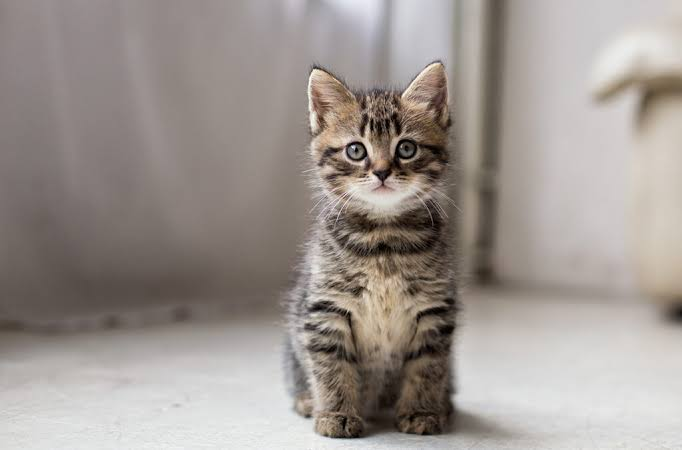

In [132]:
sample_path = Path(
    image_df.iloc[0]["image_path"]
)

sample_expected = (
    image_df.iloc[0]["expected"]
)

sample_image = Image.open(
    sample_path
).convert("RGB")

print("Expected:", sample_expected)
print("Original size:", sample_image.size)

display(sample_image)

## 7. CLIP image preprocessing

The exact preprocessing pipeline returned by the same CLIP checkpoint is used.

This is essential because CLIP image embeddings depend on resize, crop, pixel
normalization, and other preprocessing choices.

In [133]:
sample_tensor = preprocess(
    sample_image
)

print(
    "Preprocessed shape:",
    sample_tensor.shape
)

Preprocessed shape: torch.Size([3, 224, 224])


In [134]:
sample_batch = (
    sample_tensor
    .unsqueeze(0)
    .to(device)
)

print(
    "Batch shape:",
    sample_batch.shape
)

print(
    "Device:",
    sample_batch.device
)

Batch shape: torch.Size([1, 3, 224, 224])
Device: cuda:0


# Encode one image

In [135]:
with torch.no_grad():

    sample_image_embedding = (
        clip_model.encode_image(
            sample_batch
        )
    )

print(
    "Raw image embedding:",
    sample_image_embedding.shape
)

Raw image embedding: torch.Size([1, 512])


# L2-normalize the image embedding

In [136]:
sample_image_embedding = F.normalize(
    sample_image_embedding,
    dim=-1
)

print(
    "Embedding norm:",
    sample_image_embedding
    .norm(dim=-1)
    .item()
)

Embedding norm: 1.0


# Feed image embedding directly into decoder

In [137]:
generated_ids = generate_greedy(
    decoder,
    sample_image_embedding
)

generated_noun = decode_tokens(
    generated_ids
)

print("Expected :", sample_expected)
print("Generated:", generated_noun)
print("Token IDs:", generated_ids)

Expected : cat
Generated: cat
Token IDs: [17]


# Build a reusable image encoder function

In [138]:
@torch.no_grad()
def encode_image(
    image_path
):

    image = Image.open(
        image_path
    ).convert("RGB")

    tensor = preprocess(
        image
    )

    tensor = (
        tensor
        .unsqueeze(0)
        .to(device)
    )

    embedding = (
        clip_model.encode_image(
            tensor
        )
    )

    embedding = F.normalize(
        embedding,
        dim=-1
    )

    return embedding

## 8. Zero-shot image inference

Every test image is:

1. preprocessed,
2. encoded with the frozen CLIP image encoder,
3. L2-normalized,
4. passed directly into the unchanged decoder,
5. decoded greedily into an object noun.

No image-label training is performed.

In [139]:
image_predictions = []

for _, row in image_df.iterrows():

    image_embedding = encode_image(
        row["image_path"]
    )

    generated_ids = generate_greedy(
        decoder,
        image_embedding
    )

    generated_noun = decode_tokens(
        generated_ids
    )

    image_predictions.append(
        generated_noun
    )

## Build results table

In [140]:
image_results = image_df.copy()

image_results[
    "generated"
] = image_predictions

image_results[
    "correct"
] = (
    image_results["expected"]
    ==
    image_results["generated"]
)

display(
    image_results
)

,image_path,expected,generated,correct
0,/content/drive/MyDrive/mini_novic_storage/data...,cat,cat,True
1,/content/drive/MyDrive/mini_novic_storage/data...,cat,cat,True
2,/content/drive/MyDrive/mini_novic_storage/data...,cat,cat,True
3,/content/drive/MyDrive/mini_novic_storage/data...,cat,cat,True
4,/content/drive/MyDrive/mini_novic_storage/data...,dog,dog,True
5,/content/drive/MyDrive/mini_novic_storage/data...,dog,dog,True
6,/content/drive/MyDrive/mini_novic_storage/data...,dog,dog,True
7,/content/drive/MyDrive/mini_novic_storage/data...,dog,dog,True
8,/content/drive/MyDrive/mini_novic_storage/data...,fire truck,fire truck,True
9,/content/drive/MyDrive/mini_novic_storage/data...,fire truck,fire truck,True


## Exact image accuracy

In [141]:
image_accuracy = (
    image_results[
        "correct"
    ].mean()
)

print(
    f"Zero-shot image exact accuracy: "
    f"{image_accuracy * 100:.2f}%"
)

Zero-shot image exact accuracy: 85.00%


# Per-class image accuracy

In [142]:
per_class_image_accuracy = (
    image_results
    .groupby(
        "expected"
    )["correct"]
    .agg(
        [
            "mean",
            "count"
        ]
    )
    .reset_index()
)

per_class_image_accuracy[
    "accuracy_percent"
] = (
    per_class_image_accuracy[
        "mean"
    ] * 100
)

per_class_image_accuracy = (
    per_class_image_accuracy
    .sort_values(
        "accuracy_percent"
    )
)

display(
    per_class_image_accuracy
)

,expected,mean,count,accuracy_percent
3,chair,0.25,4,25.0
9,truck,0.50,4,50.0
0,airplane,0.75,4,75.0
1,bus,1.00,4,100.0
4,coffee mug,1.00,4,100.0
5,dog,1.00,4,100.0
6,fire truck,1.00,4,100.0
2,cat,1.00,4,100.0
7,helicopter,1.00,4,100.0
8,laptop,1.00,4,100.0


# Inspect failures

In [143]:
image_failures = (
    image_results[
        ~image_results[
            "correct"
        ]
    ]
)

print(
    "Number of failures:",
    len(image_failures)
)

display(
    image_failures
)

Number of failures: 6


,image_path,expected,generated,correct
20,/content/drive/MyDrive/mini_novic_storage/data...,chair,office chair,False
22,/content/drive/MyDrive/mini_novic_storage/data...,chair,office chair,False
23,/content/drive/MyDrive/mini_novic_storage/data...,chair,office chair,False
30,/content/drive/MyDrive/mini_novic_storage/data...,airplane,train,False
33,/content/drive/MyDrive/mini_novic_storage/data...,truck,cat,False
34,/content/drive/MyDrive/mini_novic_storage/data...,truck,fire truck,False


# Display failure images

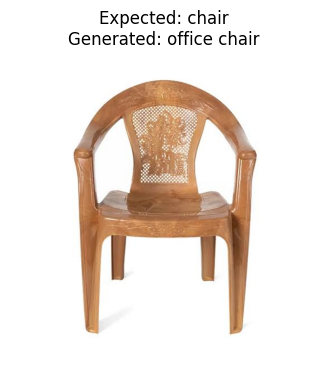

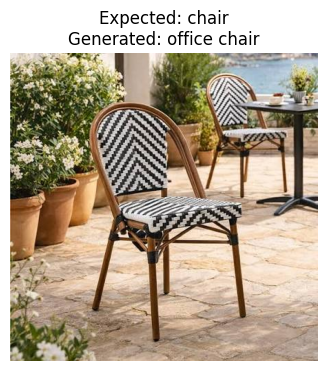

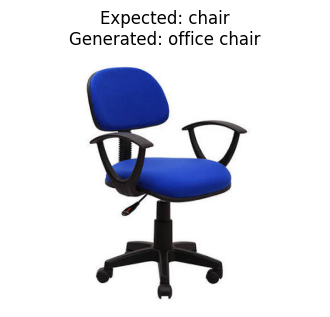

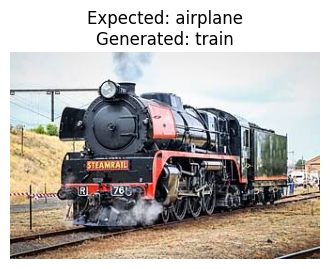

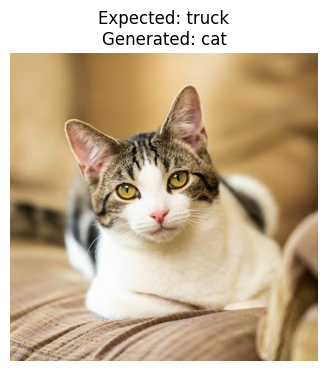

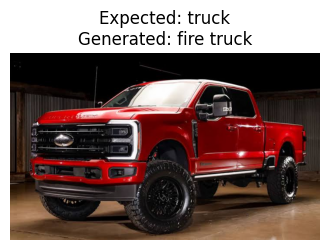

In [144]:
for _, row in image_failures.head(10).iterrows():

    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    plt.figure(
        figsize=(4, 4)
    )

    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Expected: {row['expected']}\n"
        f"Generated: {row['generated']}"
    )

    plt.show()

Here note that, I have intentionally add two incorrect image classes to obesrve the behaviour. (train as airplane and cat as truck)

## 9. Text-image embedding comparison

Although CLIP image and text embeddings represent related semantic concepts,
matching image/text pairs do not produce identical vectors.

The following experiment compares an image embedding against several text
descriptions of the expected object.

In [145]:
sample_expected = (
    image_df.iloc[0]["expected"]
)

text_prompts = [
    sample_expected,
    f"a photo of a {sample_expected}",
    f"an image of a {sample_expected}",
    f"the image contains a {sample_expected}",
]

Tokenize:

In [146]:
text_tokens = clip_tokenizer(
    text_prompts
).to(device)

Encode:

In [147]:
with torch.no_grad():

    text_embeddings = (
        clip_model.encode_text(
            text_tokens
        )
    )

text_embeddings = F.normalize(
    text_embeddings,
    dim=-1
)

Image embedding:

In [148]:
image_embedding = encode_image(
    image_df.iloc[0]["image_path"]
)

Similarities:

In [149]:
similarities = (
    image_embedding
    @ text_embeddings.T
)[0]

for prompt, similarity in zip(
    text_prompts,
    similarities.cpu().tolist()
):

    print(
        f"{prompt:40s} "
        f"{similarity:.4f}"
    )

cat                                      0.2887
a photo of a cat                         0.3210
an image of a cat                        0.3127
the image contains a cat                 0.2979


## Calculate angular distance

In [150]:
best_similarity = similarities.max()

best_similarity = torch.clamp(
    best_similarity,
    -1.0,
    1.0
)

angle_radians = torch.acos(
    best_similarity
)

angle_degrees = torch.rad2deg(
    angle_radians
)

print(
    "Best cosine similarity:",
    best_similarity.item()
)

print(
    "Angular distance:",
    angle_degrees.item(),
    "degrees"
)

Best cosine similarity: 0.3209594190120697
Angular distance: 71.27904510498047 degrees


## Optional but very useful: nearest training text embedding

Let's see which cached text embedding is closest to an image.

In [151]:
cached_text_embeddings = (
    embedding_cache[
        "embeddings"
    ]
)

cached_text_embeddings = (
    cached_text_embeddings.to(device)
)

In [152]:
image_embedding = encode_image(
    image_df.iloc[0]["image_path"]
)

similarities = (
    image_embedding
    @ cached_text_embeddings.T
)[0]

top_indices = torch.topk(
    similarities,
    k=10
).indices.cpu()

Display:

In [153]:
nearest_records = []

for idx in top_indices:

    idx = idx.item()

    nearest_records.append({
        "caption":
            embedding_cache[
                "captions"
            ][idx],

        "noun":
            embedding_cache[
                "noun_text"
            ][idx],

        "similarity":
            similarities[
                idx
            ].item()
    })

nearest_df = pd.DataFrame(
    nearest_records
)

display(nearest_df)

,caption,noun,similarity
0,this image shows a cat,cat,0.327528
1,a picture of a cat,cat,0.325558
2,a high-quality photo of a cat,cat,0.322729
3,a photo of a cat,cat,0.320959
4,this photograph shows a cat,cat,0.320467
5,A cat viewed from the front,cat,0.317902
6,a photograph containing a cat,cat,0.316403
7,an image of a cat,cat,0.312702
8,a photograph of a cat,cat,0.311290
9,a clear photo of a cat,cat,0.307992


# Save image results

In [154]:
image_results.to_csv(
    RESULT_DIR
    / "zero_shot_image_predictions.csv",
    index=False
)

In [155]:
per_class_image_accuracy.to_csv(
    RESULT_DIR
    / "per_class_image_accuracy.csv",
    index=False
)

# Save summary

In [156]:
summary = pd.DataFrame([
    {
        "num_images":
            len(image_results),

        "num_classes":
            image_results[
                "expected"
            ].nunique(),

        "zero_shot_exact_accuracy":
            image_accuracy,

        "decoder_checkpoint_epoch":
            checkpoint["epoch"],

        "text_validation_accuracy":
            1.0,
    }
])

display(summary)

,num_images,num_classes,zero_shot_exact_accuracy,decoder_checkpoint_epoch,text_validation_accuracy
0,40,10,0.85,29,1.0


In [157]:
summary.to_csv(
    RESULT_DIR
    / "summary_metrics.csv",
    index=False
)

# Conclusions

This notebook performed the first zero-shot text-to-image transfer experiment
for Mini-NOVIC.

The decoder was trained only from CLIP text embeddings.

No image-label training or decoder fine-tuning was performed.

The inference pipeline was:

image
→ frozen CLIP image encoder
→ L2-normalized image embedding
→ text-trained prefix mapper
→ text-trained autoregressive Transformer
→ generated object noun

This experiment therefore tests whether semantic knowledge learned from the CLIP
text embedding distribution transfers to the CLIP image embedding distribution.

The image accuracy should be interpreted separately from the 100% held-out text
embedding accuracy achieved in Notebook 04.

A substantial reduction in image accuracy would indicate that the autoregressive
decoder itself is functioning correctly, but that the CLIP text-image modality
gap limits direct transfer.

This motivates the next Mini-NOVIC stage:

clean text embeddings
→ noisy text embeddings
→ decoder training
→ zero-shot image evaluation

The next experiments will compare:

A0: no embedding noise
A1: normalized Gaussian embedding noise
A2: NOVIC-style unit-norm/angular noise

All variants will be evaluated on exactly the same controlled image test set.